### HR-pQCT parameters: correlation matrices

Author: Simone Poncioni, MSB

Date: 31.03.2025

Data: HR-pQCT database of the University of Bern, Switzerland

In [1]:
# Create a user library directory if it doesn't exist
user_lib <- "~/R/library"
dir.create(user_lib, recursive = TRUE, showWarnings = FALSE)

# Tell R to use this directory for new packages
.libPaths(c(user_lib, .libPaths()))

# Function to safely install and load packages
install_and_load <- function(pkg) {
  if (!require(pkg, character.only = TRUE, quietly = TRUE)) {
    install.packages(pkg, lib = user_lib)
    library(pkg, character.only = TRUE)
  }
}

# Install and load all required packages
pkgs <- c("Hmisc", "corrplot", "ggplot2", "RColorBrewer", 
          "pdftools", "png", "IRdisplay", "magick", "paletteer")

# Apply the function to each package
invisible(sapply(pkgs, install_and_load))


Attaching package: ‘Hmisc’


The following objects are masked from ‘package:base’:

    format.pval, units


corrplot 0.95 loaded

Using poppler version 24.02.0

Linking to ImageMagick 6.9.12.98
Enabled features: fontconfig, freetype, fftw, heic, lcms, pango, raw, webp, x11
Disabled features: cairo, ghostscript, rsvg

Using 16 threads



In [2]:
# Filtering, correlation, and plotting functions

# Code ideas from:
# https://cran.r-project.org/web/packages/corrplot/vignettes/corrplot-intro.html
# https://www.sthda.com/english/wiki/visualize-correlation-matrix-using-correlogram

filter_dataframe <- function(df, keeps, drops_c) {
  df_filtered <- df[, grepl(keeps, names(df))]
  df_filtered <- df_filtered[, colSums(is.na(df_filtered)) < nrow(df_filtered)]
  drops_c <- paste(drops_f, drops_specific, sep = "|")
  drops <- grep(drops_c, names(df_filtered), value = TRUE)
  df_filtered <- df_filtered[, !(names(df_filtered) %in% drops)]
  df_filtered <- na.omit(df_filtered)
  return(df_filtered)
}

correlation_p_matrix <- function(mat, ...) {
  mat <- as.matrix(mat)
  n <- ncol(mat)
  p.mat <- matrix(NA, n, n)
  diag(p.mat) <- 0
  for (i in 1:(n - 1)) {
    for (j in (i + 1):n) {
      tmp <- cor.test(mat[, i], mat[, j], alternative="two.sided", method="pearson", ...)
      p.mat[i, j] <- p.mat[j, i] <- tmp$p.value
    }
  }
  colnames(p.mat) <- rownames(p.mat) <- colnames(mat)
  return(p.mat)
}

In [3]:
generate_corrplot <- function(df, filename, plot_title, basepath) {
  df_filtered <- filter_dataframe(df, keeps, drops_c)
  # Split all column names before '[' and take the first part
  colnames(df_filtered) <- sub("\\[.*", "", colnames(df_filtered))
  corrmatrix <- cor(as.matrix(df_filtered))
  p.mat <- correlation_p_matrix(df_filtered)
  
  # Clean column names by removing "Tibia: " prefix
  cleaned_colnames <- gsub("Tibia: ", "", colnames(corrmatrix))
  colnames(corrmatrix) <- cleaned_colnames
  rownames(corrmatrix) <- cleaned_colnames
  colnames(p.mat) <- cleaned_colnames
  rownames(p.mat) <- cleaned_colnames

  # print p.mat
  print.char.matrix(p.mat, quote = FALSE)
  
  fname <- file.path(basepath, filename)
  pdf(file = fname, width = 12, height = 12)
  
  # Reduce bottom margin (first value in mar)
  par(mar = c(0.1, 0.5, 3, 0.5), oma = c(0, 0, 0, 0), bg = "white", xpd=TRUE)
  pal_colors <- c("#BF360C", "#E64A19", "#FF8A65", "#FFCCBC","#FFFFFF","#7FC8C9", "#35A7A7", "#018786")
  col <- colorRampPalette(pal_colors)

  corrplot(corrmatrix, method = "color", col = col(200),
           type = "upper", order = "AOE",
           addCoef.col = "black",  # Color of the p-values
           number.font = 1,        # Use normal font for p-values
           # Increase text sizes
           tl.col = "black", tl.srt = 45, tl.cex = 1.25,
           cl.cex = 1.25,          # Larger color legend text
           number.cex = 1.25,      # Larger correlation coefficients
           p.mat = p.mat, sig.level = 0.005, insig = "blank",
           diag = FALSE,
           # Fill more of the plot area
           mar = c(0, 0, 0, 0),    # Remove internal margins in corrplot
           # Change color legend position to right side to save vertical space
           cl.pos = "r",
           # Reduce color legend ratio
           cl.ratio = 0.2,
           cl.align = "c"          # Center the color legend
  )
  
  # Larger plot title positioned closer to the top of the plot
  mtext(plot_title, side = 3, line = -5.5, cex = 2.0, font = 2, outer = TRUE)
  dev.off()
  
  png_path <- sub(".pdf$", ".png", fname)
  image <- image_read(fname)
  image_write(image, path = png_path, format = "png")
  
  display_png(file = png_path)
}

In [4]:
# Import dataframe
# df <- read.csv('/home/simoneponcioni/Documents/01_PHD/03_Methods/HR-pQCT_database/00_DB/HR-pQCT_database_2025-01-28.csv', check.names = FALSE)
df <- read.csv('/home/simoneponcioni/Documents/01_PHD/03_Methods/HR-pQCT_database/00_DB/HR-pQCT_database_expanded_2025-06-16_16-18.csv', check.names = FALSE)

# Remove non-numeric columns
df_numeric <- df[sapply(df, is.numeric)]

In [5]:
# General settings
basepath = "/home/simoneponcioni/Documents/01_PHD/03_Methods/HR-pQCT_database/03_EVALUATION/03_correlation-matrix"
drops_f = "Measurement number|side|Time difference Frax & HRpQCT \\[days\\]"

+----------------------------+---------------------+--------------------+---------------------+--------------------+---------------------+--------------------+---------------------+---------------------+---------------------+---------------------+---------------------+---------------------+---------------------+---------------------+--------------------+--------------------+---------------------+---------------------+---------------------+---------------------+---------------------+------------------+
|                   Tot.vBMD |                    0|1.44196188478456e-27|   0.0104997061742311| 0.00185719550995771| 1.73604790249521e-67|3.55506273355292e-14| 3.50793150944372e-60|2.80012638557734e-105|7.46314432292009e-122|   0.0402513737859964|3.66817567312844e-171| 1.14458574285933e-48| 8.70624343304941e-71| 7.02011605296316e-21| 1.4191259753741e-07|  0.0151596883283004| 1.36546328892119e-51|8.26485964309369e-172|  7.3861639675352e-53| 1.41818227599025e-58| 1.66666585969634e-79| 0.214

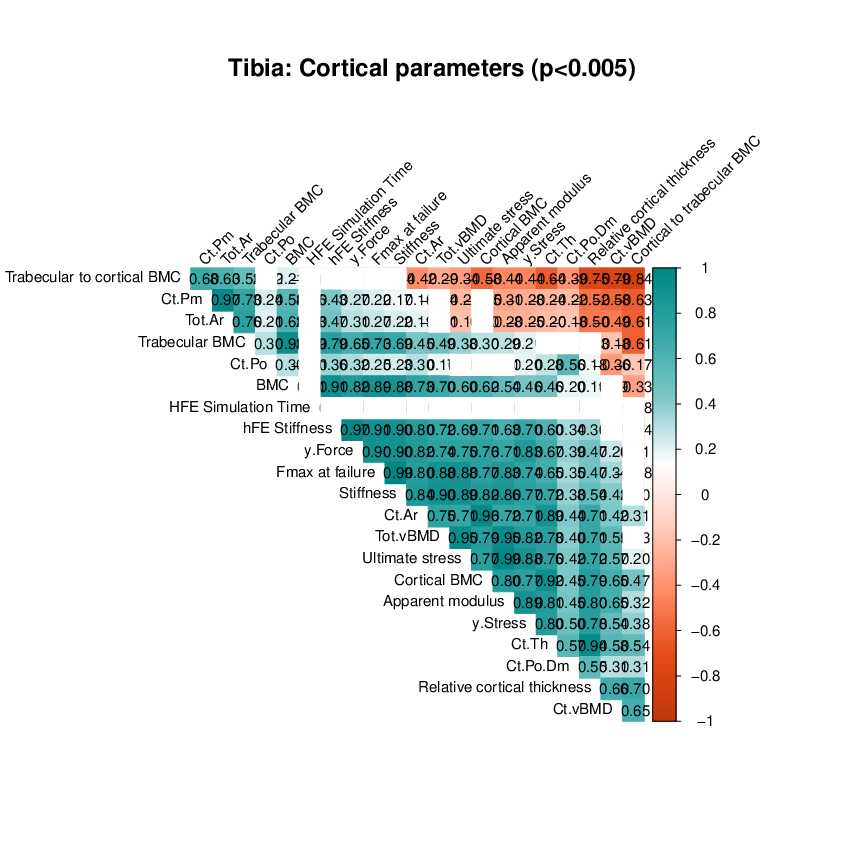

In [6]:
# Tibia: Cortical parameters
drops_specific = "Radius|Tb."
keeps = "Tibia|Ct..\\."
filename = "tibia_cort_correlation_matrix.pdf"
plot_title = "Tibia: Cortical parameters (p<0.005)"

generate_corrplot(df, filename, plot_title, basepath)

+----------------------------+---------------------+---------------------+---------------------+---------------------+---------------------+---------------------+--------------------+---------------------+--------------------+---------------------+--------------------+---------------------+---------------------+---------------------+---------------------+---------------------+---------------------+--------------------+---------------------+--------------------+--------------------+--------------------+---------------------+---------------------+---------------------+---------------------+--------------------+------------------+
|                   Tot.vBMD |                    0|1.64402666430678e-109|4.20476044120688e-151| 2.49719014050462e-75|1.21317959590016e-107| 8.77846977624587e-28|1.34873394652954e-53| 3.30721466472715e-35|1.21492717992493e-15| 4.86258582384122e-05|4.81923899126614e-05| 4.88139194925883e-05| 2.19585031846326e-98|1.01880602692593e-113|   0.0256605883725579|9.30167

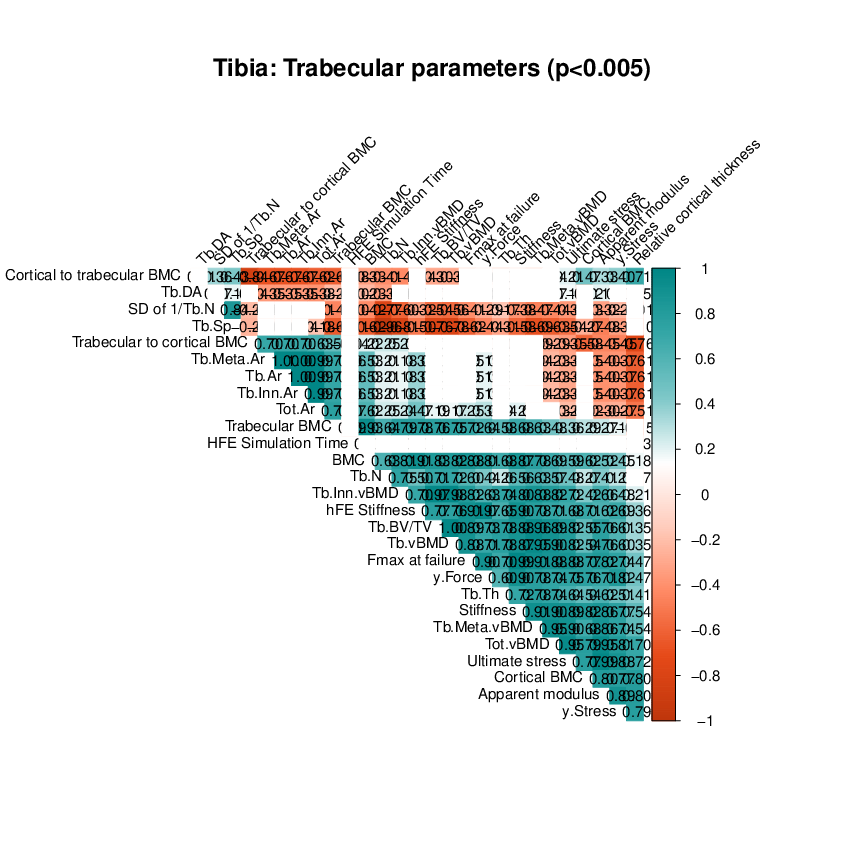

In [7]:
# Tibia: Trabecular parameters
drops_specific = "Radius|Ct."
keeps = "Tibia|Tb..\\."
filename = "tibia_trab_correlation_matrix.pdf"
plot_title = "Tibia: Trabecular parameters (p<0.005)"
generate_corrplot(df, filename, plot_title, basepath)

+------------------------------------+---------------------+--------------------+---------------------+--------------------+---------------------+--------------------+---------------------+---------------------+---------------------+---------------------+---------------------+---------------------+---------------------+---------------------+---------------------+---------------------+---------------------+---------------------+---------------------+---------------------+---------------------+-------------------+
|                   Radius: Tot.vBMD |                    0|7.33470970750623e-33|  0.00408966369526418|  0.0664659113677758|3.12455152754677e-101|  0.0528904173841887| 5.94690275391542e-48| 3.53429454017005e-79| 1.93350050462581e-95|  0.00717020658165478|1.52982867145864e-150| 7.52649025339777e-43|  1.0949822773674e-64| 1.97081557328543e-15|   0.0603637386599181|    0.714201773458317| 8.84797757206648e-96|8.28253204418527e-207| 1.07515865802463e-35| 4.44548334904996e-53| 3.5615

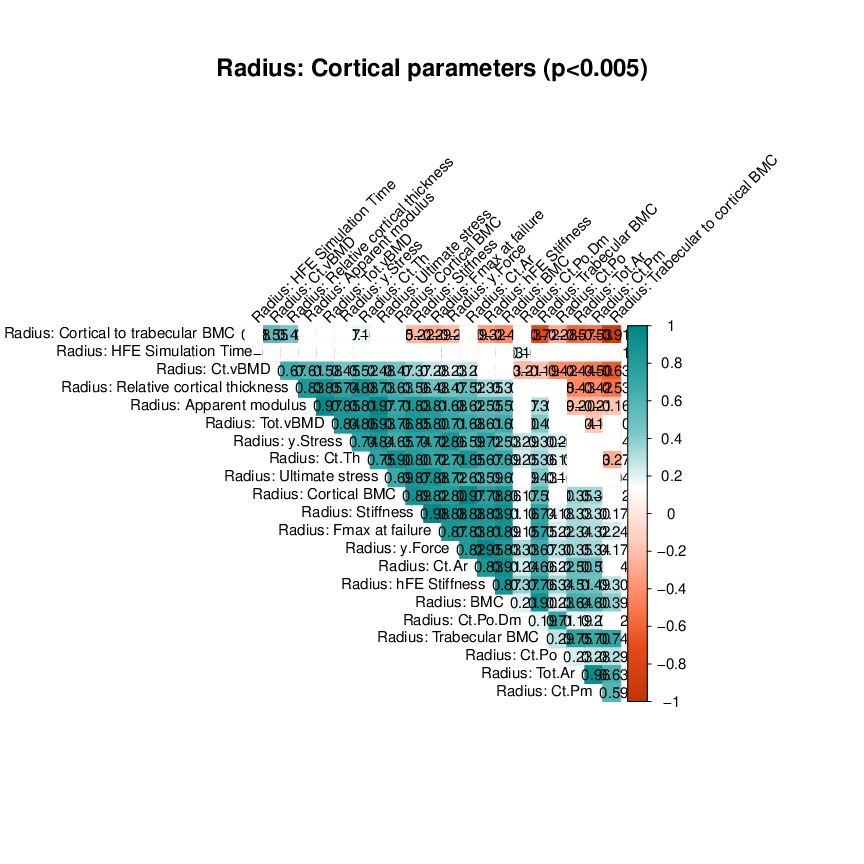

In [8]:
# Radius: Cortical parameters
drops_specific = "Tibia|Tb."
keeps = "Radius|Ct..\\."
filename = "radius_cort_correlation_matrix.pdf"
plot_title = "Radius: Cortical parameters (p<0.005)"
generate_corrplot(df, filename, plot_title, basepath)

+------------------------------------+---------------------+---------------------+---------------------+---------------------+---------------------+---------------------+--------------------+---------------------+---------------------+---------------------+---------------------+---------------------+---------------------+---------------------+---------------------+---------------------+---------------------+---------------------+---------------------+---------------------+---------------------+--------------------+---------------------+---------------------+---------------------+---------------------+--------------------+------------------+
|                   Radius: Tot.vBMD |                    0| 3.73946029570012e-87| 7.20399169704308e-96| 9.89635970682841e-74| 2.88074241323779e-86| 2.16792385646061e-39| 1.5072389604112e-36| 7.74555832735135e-39|  2.8149865028642e-18| 1.49494218202737e-08|  1.4992505309409e-08|  1.3856797068466e-08| 1.17831691552327e-76| 7.83136199625791e-93|   0.0

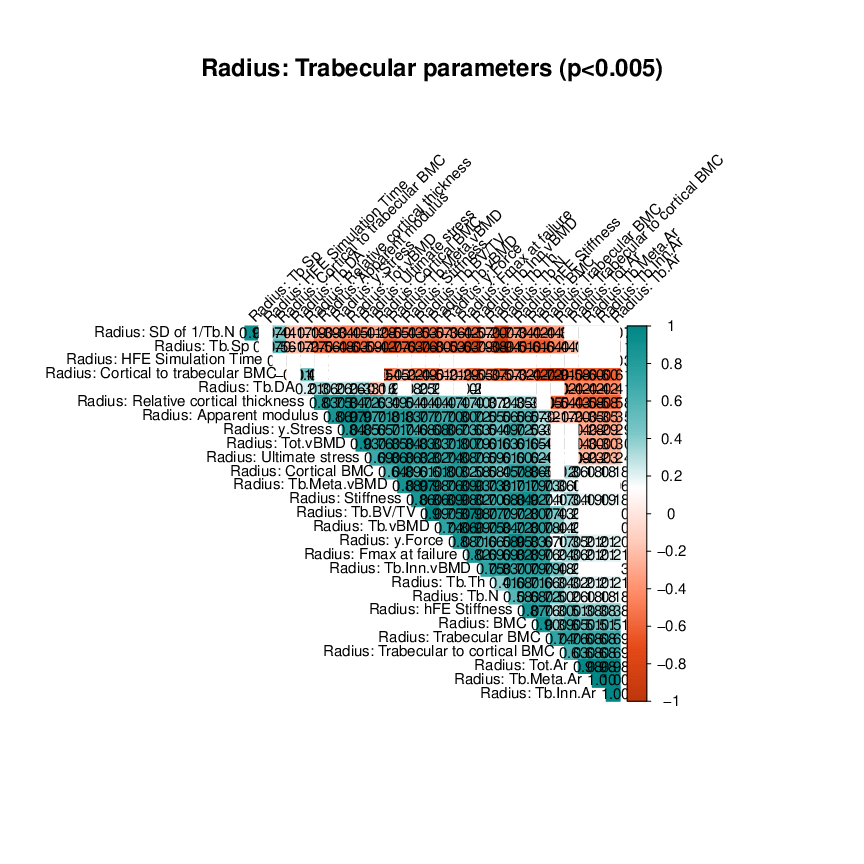

In [9]:
# Radius: Trabecular parameters
drops_specific = "Tibia|Ct."
keeps = "Radius|Tb..\\."
filename = "radius_trab_correlation_matrix.pdf"
plot_title = "Radius: Trabecular parameters (p<0.005)"
generate_corrplot(df, filename, plot_title, basepath)

In [10]:
# Create correlogram on radar-specific parameters
# Import dataframe
df <- read.csv('/home/simoneponcioni/Documents/01_PHD/03_Methods/HR-pQCT_database/00_DB/HR-pQCT_database_full_2025-01-28.csv', check.names = FALSE)

# Remove non-numeric columns
df_numeric <- df[sapply(df, is.numeric)]

# Create dataframes with specific columns for Radius and Tibia
# Define mapping of original column names to standardized names
radius_cols <- c(
  "Radius: Tt.vBMD [mg HA/cmm]" = "Tot.vBMD",
  "Radius: Ct.vBMD [mg HA/cmm]" = "Ct.vBMD",
  "Radius: Tb.BV/TV [1]" = "Tb.BVTV",
  "Radius: Relative cortical thickness [-]" = "Rel.Ct.Th",
  "Radius: Area ratio (Ct./Tb.) [-]" = "Ct./Tb.Ar",
  "Radius: poncioni_yield_force" = "sigma[y]",
  "Radius: Fmax at failure [N]" = "F[max]",
  "Radius: Ct.Th [mm]" = "Ct.Th",
  "Radius: Ct.Po [1]" = "Ct.Po",
  "Radius: Tb.vBMD [mg HA/cmm]" = "Tb.vBMD",
  "Radius: Tb.N [1/mm]" = "Tb.N",
  "Radius: Tb.Sp [mm]" = "Tb.Sp",
  "Radius: Tb.Th [mm]" = "Tb.Th"
)

tibia_cols <- c(
  "Tibia: Tt.vBMD [mg HA/cmm]" = "Tot.vBMD",
  "Tibia: Ct.vBMD [mg HA/cmm]" = "Ct.vBMD",
  "Tibia: Tb.BV/TV [1]" = "Tb.BVTV",
  "Tibia: Relative cortical thickness [-]" = "Rel.Ct.Th",
  "Tibia: Area ratio (Ct./Tb.) [-]" = "Ct./Tb.Ar",
  "Tibia: poncioni_yield_force" = "sigma[y]",
  "Tibia: Fmax at failure [N]" = "F[max]",
  "Tibia: Ct.Th [mm]" = "Ct.Th",
  "Tibia: Ct.Po [1]" = "Ct.Po",
  "Tibia: Tb.vBMD [mg HA/cmm]" = "Tb.vBMD",
  "Tibia: Tb.N [1/mm]" = "Tb.N",
  "Tibia: Tb.Sp [mm]" = "Tb.Sp",
  "Tibia: Tb.Th [mm]" = "Tb.Th"
)

# Extract and rename radius data
radius_df <- df[, names(radius_cols)]
colnames(radius_df) <- radius_cols
radius_df$Site <- "Radius"

# Extract and rename tibia data
tibia_df <- df[, names(tibia_cols)]
colnames(tibia_df) <- tibia_cols
tibia_df$Site <- "Tibia"

# Combine the dataframes
combined_df <- rbind(radius_df, tibia_df)

# Remove rows with NA values
combined_df <- na.omit(combined_df)

# General settings
basepath <- "/home/simoneponcioni/Documents/01_PHD/03_Methods/HR-pQCT_database/03_EVALUATION/correlation-matrix/"
filename <- "hr_pqct_selected_parameters_correlation_matrix.pdf"
plot_title <- "HR-pQCT key parameters correlation (p<0.005)"

# Generate correlogram for the combined dataframe
generate_combined_corrplot <- function(df, filename, plot_title, basepath) {
  # Remove the Site column
  df_filtered <- df[, !names(df) %in% c("Site")]
  
  # Calculate correlation matrix and p-values
  corrmatrix <- cor(as.matrix(df_filtered))
  p.mat <- correlation_p_matrix(df_filtered)
  
  # Create the output file
  fname <- file.path(basepath, filename)
  pdf(file = fname, width = 12, height = 12)
  
  # Set up plot parameters
  par(mar = c(0.1, 0.5, 3, 0.5), oma = c(0, 0, 0, 0), bg = "white", xpd=TRUE)
  pal_colors <- c("#BF360C", "#E64A19", "#FF8A65", "#FFCCBC","#FFFFFF","#7FC8C9", "#35A7A7", "#018786")
  col <- colorRampPalette(pal_colors)

  # Create the correlogram
  corrplot(corrmatrix, method = "color", col = col(200),
           type = "upper", order = "AOE",
           addCoef.col = "black",
           number.font = 1,
           tl.col = "black", tl.srt = 45, tl.cex = 1.25,
           cl.cex = 1.25,
           number.cex = 1.25,
           p.mat = p.mat, sig.level = 0.005, insig = "blank",
           diag = FALSE,
           mar = c(0, 0, 0, 0),
           cl.pos = "r",
           cl.ratio = 0.2,
           cl.align = "c"
  )
  
  # Add title
  mtext(plot_title, side = 3, line = -5.5, cex = 2.0, font = 2, outer = TRUE)
  dev.off()
  
  # Create PNG version for display
  png_path <- sub("\\.pdf$", ".png", fname)
  image <- image_read(fname)
  image_write(image, path = png_path, format = "png")
  
  display_png(file = png_path)
}

# Generate the correlogram with just the selected parameters
generate_combined_corrplot(combined_df, filename, plot_title, basepath)

ERROR: Error in cor.test.default(mat[, i], mat[, j], alternative = "two.sided", : 'x' must be a numeric vector


In [11]:
# Create correlogram on radar-specific parameters
# Import dataframe
df <- read.csv('/home/simoneponcioni/Documents/01_PHD/03_Methods/HR-pQCT_database/00_DB/HR-pQCT_database_full_2025-01-28.csv', check.names = FALSE)

# only keep study name Nodaratis
df <- df[df$Study == "Nodaratis", ]

# Remove non-numeric columns
df_numeric <- df[sapply(df, is.numeric)]

# Create dataframes with specific columns for Radius and Tibia
# Define mapping of original column names to standardized names
radius_cols <- c(
  "Radius: Tt.vBMD [mg HA/cmm]" = "Tot.vBMD",
  "Radius: Ct.vBMD [mg HA/cmm]" = "Ct.vBMD",
  "Radius: Tb.BV/TV [1]" = "Tb.BVTV",
  "Radius: Relative cortical thickness [-]" = "Rel.Ct.Th",
  "Radius: Area ratio (Ct./Tb.) [-]" = "Ct./Tb.Ar",
  "Radius: poncioni_yield_force" = "sigma[y]",
  "Radius: Fmax at failure [N]" = "F[max]",
  "Radius: Ct.Th [mm]" = "Ct.Th",
  "Radius: Ct.Po [1]" = "Ct.Po",
  "Radius: Tb.vBMD [mg HA/cmm]" = "Tb.vBMD",
  "Radius: Tb.N [1/mm]" = "Tb.N",
  "Radius: Tb.Sp [mm]" = "Tb.Sp",
  "Radius: Tb.Th [mm]" = "Tb.Th"
)

tibia_cols <- c(
  "Tibia: Tt.vBMD [mg HA/cmm]" = "Tot.vBMD",
  "Tibia: Ct.vBMD [mg HA/cmm]" = "Ct.vBMD",
  "Tibia: Tb.BV/TV [1]" = "Tb.BVTV",
  "Tibia: Relative cortical thickness [-]" = "Rel.Ct.Th",
  "Tibia: Area ratio (Ct./Tb.) [-]" = "Ct./Tb.Ar",
  "Tibia: poncioni_yield_force" = "sigma[y]",
  "Tibia: Fmax at failure [N]" = "F[max]",
  "Tibia: Ct.Th [mm]" = "Ct.Th",
  "Tibia: Ct.Po [1]" = "Ct.Po",
  "Tibia: Tb.vBMD [mg HA/cmm]" = "Tb.vBMD",
  "Tibia: Tb.N [1/mm]" = "Tb.N",
  "Tibia: Tb.Sp [mm]" = "Tb.Sp",
  "Tibia: Tb.Th [mm]" = "Tb.Th"
)

# Extract and rename radius data
radius_df <- df[, names(radius_cols)]
colnames(radius_df) <- radius_cols
radius_df$Site <- "Radius"

# Extract and rename tibia data
tibia_df <- df[, names(tibia_cols)]
colnames(tibia_df) <- tibia_cols
tibia_df$Site <- "Tibia"

# Combine the dataframes
combined_df <- rbind(radius_df, tibia_df)


combined_df$Fn.BMD <- df$`Femoral neck BMD (g/cm2)`


# Remove rows with NA values
combined_df <- na.omit(combined_df)

# General settings
basepath <- "/home/simoneponcioni/Documents/01_PHD/03_Methods/HR-pQCT_database/03_EVALUATION/correlation-matrix/"
filename <- "hr_pqct_selected_parameters_correlation_matrix_nodaratis.pdf"
plot_title <- "HR-pQCT key parameters correlation (p<0.005)"

# Generate correlogram for the combined dataframe
generate_combined_corrplot <- function(df, filename, plot_title, basepath) {
  # Remove the Site column
  df_filtered <- df[, !names(df) %in% c("Site")]
  
  # Calculate correlation matrix and p-values
  corrmatrix <- cor(as.matrix(df_filtered))
  p.mat <- correlation_p_matrix(df_filtered)
  
  # Create the output file
  fname <- file.path(basepath, filename)
  pdf(file = fname, width = 12, height = 12)
  
  # Set up plot parameters
  par(mar = c(0.1, 0.5, 3, 0.5), oma = c(0, 0, 0, 0), bg = "white", xpd=TRUE)
  pal_colors <- c("#BF360C", "#E64A19", "#FF8A65", "#FFCCBC","#FFFFFF","#7FC8C9", "#35A7A7", "#018786")
  col <- colorRampPalette(pal_colors)

  # Create the correlogram
  corrplot(corrmatrix, method = "color", col = col(200),
           type = "upper", order = "AOE",
           addCoef.col = "black",
           number.font = 1,
           tl.col = "black", tl.srt = 45, tl.cex = 1.25,
           cl.cex = 1.25,
           number.cex = 1.25,
           p.mat = p.mat, sig.level = 0.005, insig = "blank",
           diag = FALSE,
           mar = c(0, 0, 0, 0),
           cl.pos = "r",
           cl.ratio = 0.2,
           cl.align = "c"
  )
  
  # Add title
  mtext(plot_title, side = 3, line = -5.5, cex = 2.0, font = 2, outer = TRUE)
  dev.off()
  
  # Create PNG version for display
  png_path <- sub("\\.pdf$", ".png", fname)
  image <- image_read(fname)
  image_write(image, path = png_path, format = "png")
  
  display_png(file = png_path)
}

# Generate the correlogram with just the selected parameters
generate_combined_corrplot(combined_df, filename, plot_title, basepath)

ERROR: Error in cor.test.default(mat[, i], mat[, j], alternative = "two.sided", : 'x' must be a numeric vector


In [12]:
### ONLY EVALUATE THE TIBIA
# Create correlogram on radar-specific parameters (tibia only)
# Import dataframe
df <- read.csv('/home/simoneponcioni/Documents/01_PHD/03_Methods/HR-pQCT_database/00_DB/HR-pQCT_database_full_2025-01-28.csv', check.names = FALSE)

# only keep study name Nodaratis
# df <- df[df$Study == "Nodaratis", ]

# Remove non-numeric columns
df_numeric <- df[sapply(df, is.numeric)]

# Create dataframe with specific columns for Tibia
# Define mapping of original column names to standardized names
tibia_cols <- c(
  "Tibia: Tt.vBMD [mg HA/cmm]" = "Tot.vBMD",
  "Tibia: Ct.vBMD [mg HA/cmm]" = "Ct.vBMD",
  "Tibia: Tb.BV/TV [1]" = "Tb.BVTV",
  "Tibia: Relative cortical thickness [-]" = "Rel.Ct.Th",
  "Tibia: Area ratio (Ct./Tb.) [-]" = "Ct./Tb.Ar",
  "Tibia: poncioni_yield_force" = "sigma[y]",
  "Tibia: Fmax at failure [N]" = "F[max]",
  "Tibia: Ct.Th [mm]" = "Ct.Th",
  "Tibia: Ct.Po [1]" = "Ct.Po",
  "Tibia: Tb.vBMD [mg HA/cmm]" = "Tb.vBMD",
  "Tibia: Tb.N [1/mm]" = "Tb.N",
  "Tibia: Tb.Sp [mm]" = "Tb.Sp",
  "Tibia: Tb.Th [mm]" = "Tb.Th"
)

# Extract and rename tibia data
tibia_df <- df[, names(tibia_cols)]
colnames(tibia_df) <- tibia_cols

# Add femoral neck BMD
tibia_df$Fn.BMD <- df$`Femoral neck BMD (g/cm2)`

# Remove rows with NA values
tibia_df <- na.omit(tibia_df)

# General settings
basepath <- "/home/simoneponcioni/Documents/01_PHD/03_Methods/HR-pQCT_database/03_EVALUATION/correlation-matrix/"
filename <- "hr_pqct_parameters_correlation_matrix_nodaratis_tibia.pdf"
plot_title <- "HR-pQCT parameters correlation (p<0.005)"

# Generate correlogram for the tibia dataframe
generate_tibia_corrplot <- function(df, filename, plot_title, basepath) {
  # Calculate correlation matrix and p-values
  corrmatrix <- cor(as.matrix(df))
  p.mat <- correlation_p_matrix(df)
  
  # Create the output file
  fname <- file.path(basepath, filename)
  pdf(file = fname, width = 12, height = 12)
  
  # Set up plot parameters
  par(mar = c(0.1, 0.5, 3, 0.5), oma = c(0, 0, 0, 0), bg = "white", xpd=TRUE)
  pal_colors <- c("#BF360C", "#E64A19", "#FF8A65", "#FFCCBC","#FFFFFF","#7FC8C9", "#35A7A7", "#018786")
  col <- colorRampPalette(pal_colors)

  # Create the correlogram
  corrplot(corrmatrix, method = "color", col = col(200),
           type = "upper", order = "AOE",
           addCoef.col = "black",
           number.font = 1,
           tl.col = "black", tl.srt = 45, tl.cex = 1.25,
           cl.cex = 1.25,
           number.cex = 1.25,
           p.mat = p.mat, sig.level = 0.005, insig = "blank",
           diag = FALSE,
           mar = c(0, 0, 0, 0),
           cl.pos = "r",
           cl.ratio = 0.2,
           cl.align = "c"
  )
  
  # Add title
  mtext(plot_title, side = 3, line = -5.5, cex = 2.0, font = 2, outer = TRUE)
  dev.off()
  
  # Create PNG version for display
  png_path <- sub("\\.pdf$", ".png", fname)
  image <- image_read(fname)
  image_write(image, path = png_path, format = "png")
  
  display_png(file = png_path)
}

# Generate the correlogram with just the tibia parameters
generate_tibia_corrplot(tibia_df, filename, plot_title, basepath)

ERROR: Error in cor.test.default(mat[, i], mat[, j], alternative = "two.sided", : 'x' must be a numeric vector


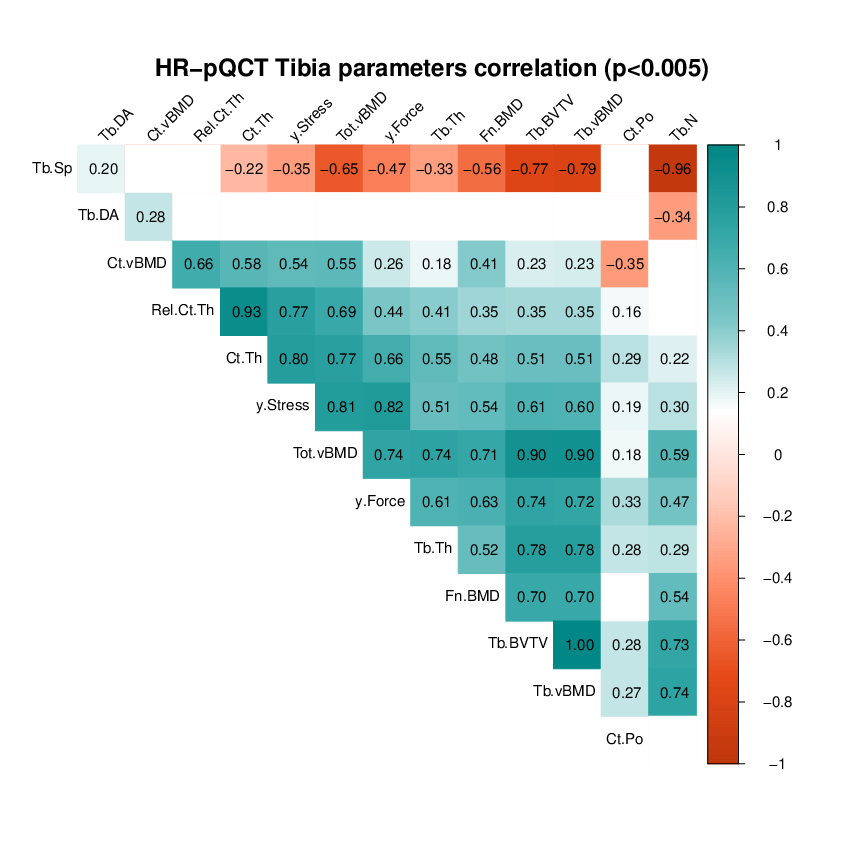

In [15]:
### ONLY EVALUATE THE TIBIA
# Create correlogram on radar-specific parameters (tibia only)
# Import dataframe
df <- read.csv('/home/simoneponcioni/Documents/01_PHD/03_Methods/HR-pQCT_database/00_DB/HR-pQCT_database_expanded_2025-06-16_16-18.csv', check.names = FALSE)

# only keep study name Nodaratis
# df <- df[df$Study == "Nodaratis", ]

# Remove non-numeric columns
df_numeric <- df[sapply(df, is.numeric)]

# Create dataframe with specific columns for Tibia
# Define mapping of original column names to standardized names
tibia_cols <- c(
  "Tibia: Tot.vBMD [mg HA/cmm]" = "Tot.vBMD",
  "Tibia: Ct.vBMD [mg HA/cmm]" = "Ct.vBMD",
  "Tibia: Tb.BV/TV [1]" = "Tb.BVTV",
  "Tibia: Relative cortical thickness [-]" = "Rel.Ct.Th",
  "Tibia: y.Force [N]" = "y.Force",
  "Tibia: y.Stress [MPa]" = "y.Stress",
  "Tibia: Ct.Th [mm]" = "Ct.Th",
  "Tibia: Ct.Po [1]" = "Ct.Po",
  "Tibia: Tb.vBMD [mg HA/cmm]" = "Tb.vBMD",
  "Tibia: Tb.N [1/mm]" = "Tb.N",
  "Tibia: Tb.Sp [mm]" = "Tb.Sp",
  "Tibia: Tb.Th [mm]" = "Tb.Th",
  "Tibia: Tb.DA" = "Tb.DA"
)

# Extract and rename tibia data
tibia_df <- df[, names(tibia_cols)]
colnames(tibia_df) <- tibia_cols

# Add femoral neck BMD
tibia_df$Fn.BMD <- df$`Femoral neck BMD (g/cm2)`

# Remove rows with NA values
tibia_df <- na.omit(tibia_df)

# General settings
basepath <- "/home/simoneponcioni/Documents/01_PHD/03_Methods/HR-pQCT_database/03_EVALUATION/03_correlation-matrix/"
filename <- "hr_pqct_parameters_correlation_matrix_nodaratis_tibia_da_paper.pdf"
plot_title <- "HR-pQCT Tibia parameters correlation (p<0.005)"

# Generate correlogram for the tibia dataframe
generate_tibia_corrplot <- function(df, filename, plot_title, basepath) {
  # Calculate correlation matrix and p-values
  corrmatrix <- cor(as.matrix(df))
  p.mat <- correlation_p_matrix(df)
  
  # Create the output file
  fname <- file.path(basepath, filename)
  pdf(file = fname, width = 12, height = 12)
  
  # Set up plot parameters
  par(mar = c(0.1, 0.5, 3, 0.5), oma = c(0, 0, 0, 0), bg = "white", xpd=TRUE)
  pal_colors <- c("#BF360C", "#E64A19", "#FF8A65", "#FFCCBC","#FFFFFF","#7FC8C9", "#35A7A7", "#018786")
  col <- colorRampPalette(pal_colors)

  # Create the correlogram
  corrplot(corrmatrix, method = "color", col = col(200),
           type = "upper", order = "AOE",
           addCoef.col = "black",
           number.font = 1,
           tl.col = "black", tl.srt = 45, tl.cex = 1.25,
           cl.cex = 1.25,
           number.cex = 1.25,
           p.mat = p.mat, sig.level = 0.005, insig = "blank",
           diag = FALSE,
           mar = c(0, 0, 0, 0),
           cl.pos = "r",
           cl.ratio = 0.2,
           cl.align = "c"
  )
  
  # Add title
  mtext(plot_title, side = 3, line = -5.5, cex = 2.0, font = 2, outer = TRUE)
  dev.off()
  
  # Create PNG version for display
  png_path <- sub("\\.pdf$", ".png", fname)
  image <- image_read(fname)
  image_write(image, path = png_path, format = "png")
  
  display_png(file = png_path)
}

# Generate the correlogram with just the tibia parameters
generate_tibia_corrplot(tibia_df, filename, plot_title, basepath)

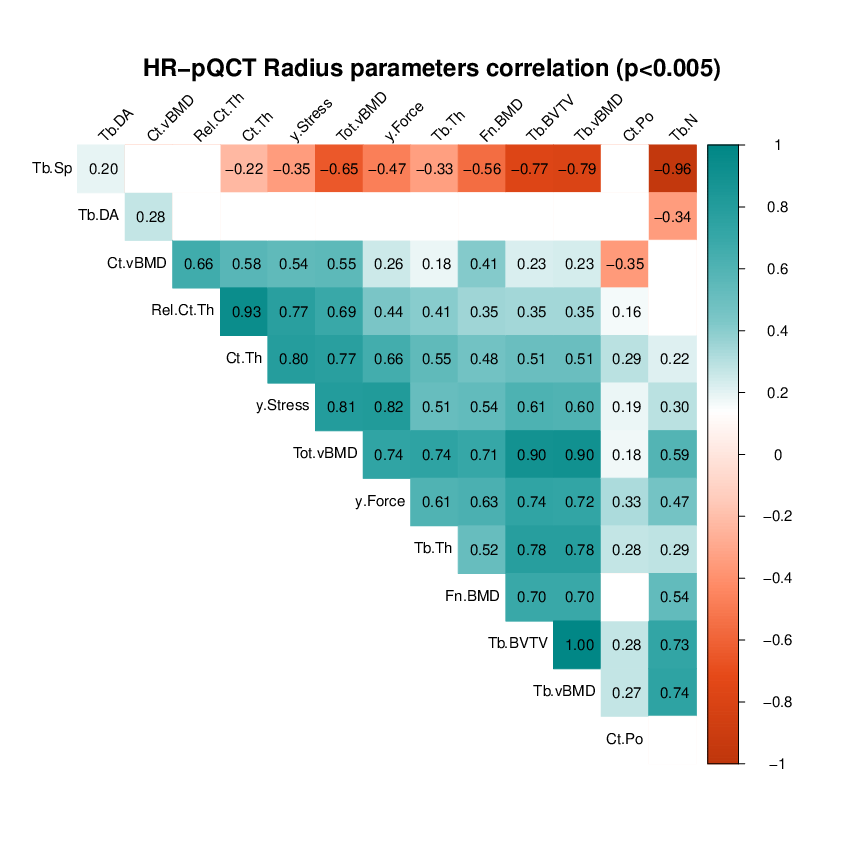

In [31]:
### ONLY EVALUATE THE RADIUS
# Create correlogram on radar-specific parameters (tibia only)

# only keep study name Nodaratis
# df <- df[df$Study == "Nodaratis", ]

# Remove non-numeric columns
df_numeric <- df[sapply(df, is.numeric)]

# Create dataframe with specific columns for Radius
# Define mapping of original column names to standardized names
radius_cols <- c(
  "Radius: Tot.vBMD [mg HA/cmm]" = "Tot.vBMD",
  "Radius: Ct.vBMD [mg HA/cmm]" = "Ct.vBMD",
  "Radius: Tb.BV/TV [1]" = "Tb.BVTV",
  "Radius: Relative cortical thickness [-]" = "Rel.Ct.Th",
  "Radius: Area ratio (Ct./Tb.) [-]" = "Ct./Tb.Ar",
  "Radius: y.Force [N]" = "y.Force",
  "Radius: y.Stress [MPa]" = "y.Stress",
  "Radius: Ct.Th [mm]" = "Ct.Th",
  "Radius: Ct.Po [1]" = "Ct.Po",
  "Radius: Tb.vBMD [mg HA/cmm]" = "Tb.vBMD",
  "Radius: Tb.N [1/mm]" = "Tb.N",
  "Radius: Tb.Sp [mm]" = "Tb.Sp",
  "Radius: Tb.Th [mm]" = "Tb.Th",
  "Radius: Tb.DA" = "Tb.DA"
)

# Extract and rename radius data
radius_df <- df[, names(radius_cols)]
colnames(radius_df) <- radius_cols

# Add femoral neck BMD
radius_df$Fn.BMD <- df$`Femoral neck BMD (g/cm2)`

# Remove rows with NA values
radius_df <- na.omit(radius_df)

# General settings
basepath <- "/home/simoneponcioni/Documents/01_PHD/03_Methods/HR-pQCT_database/03_EVALUATION/03_correlation-matrix/"
filename <- "hr_pqct_parameters_correlation_matrix_nodaratis_radius_da_paper.pdf"
plot_title <- "HR-pQCT Radius parameters correlation (p<0.005)"

# Generate correlogram for the radius dataframe
generate_radius_corrplot <- function(df, filename, plot_title, basepath) {
  # Calculate correlation matrix and p-values
  corrmatrix <- cor(as.matrix(df))
  p.mat <- correlation_p_matrix(df)
  
  # Create the output file
  fname <- file.path(basepath, filename)
  pdf(file = fname, width = 12, height = 12)
  
  # Set up plot parameters
  par(mar = c(0.1, 0.5, 3, 0.5), oma = c(0, 0, 0, 0), bg = "white", xpd=TRUE)
  pal_colors <- c("#BF360C", "#E64A19", "#FF8A65", "#FFCCBC","#FFFFFF","#7FC8C9", "#35A7A7", "#018786")
  col <- colorRampPalette(pal_colors)

  # Create the correlogram
  corrplot(corrmatrix, method = "color", col = col(200),
           type = "upper", order = "AOE",
           addCoef.col = "black",
           number.font = 1,
           tl.col = "black", tl.srt = 45, tl.cex = 1.25,
           cl.cex = 1.25,
           number.cex = 1.25,
           p.mat = p.mat, sig.level = 0.005, insig = "blank",
           diag = FALSE,
           mar = c(0, 0, 0, 0),
           cl.pos = "r",
           cl.ratio = 0.2,
           cl.align = "c"
  )
  
  # Add title
  mtext(plot_title, side = 3, line = -5.5, cex = 2.0, font = 2, outer = TRUE)
  dev.off()
  
  # Create PNG version for display
  png_path <- sub("\\.pdf$", ".png", fname)
  image <- image_read(fname)
  image_write(image, path = png_path, format = "png")
  
  display_png(file = png_path)
}

# Generate the correlogram with just the radius parameters
generate_radius_corrplot(tibia_df, filename, plot_title, basepath)